In [1]:
import os
import sys
import numpy as np
import sympy as sp
import pandas as pd
from pycalphad import Database, Model, binplot, equilibrium, calculate, variables as v
from pycalphad.plot.utils import phase_legend

from fparser import *
# from moose import fparser
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.text import Text
from matplotlib.legend_handler import HandlerLine2D

from scipy.optimize import differential_evolution, minimize, curve_fit


## Load TDB file

In [2]:
db_filename = 'tdb_filesCoCrFeNiV.TDB'   ## https://doi.org/10.1016/j.calphad.2019.05.001  | A thermodynamic description of the Co-Cr-Fe-Ni-V system for high-entropy alloy design
db = Database(db_filename)
available_phases = list(db.phases)
available_phases

['LIQUID',
 'B2_BCC',
 'BCC_A2',
 'COV3',
 'FCC_A1',
 'HCP_A3',
 'HIGH_SIGMA',
 'L12_FCC',
 'M3V',
 'NI2V',
 'NI2V7',
 'SIGMA']

In [3]:
phases = ['LIQUID','FCC_A1']
components = ['CO', 'CR', 'FE', 'Ni', 'VA']

In [4]:
constituents = list(set([i for c in db.phases[phases[0]].constituents for i in c])) # Elements 
constituents

[Species('NI', 'NI1'),
 Species('CR', 'CR1'),
 Species('FE', 'FE1'),
 Species('V', 'V1'),
 Species('CO', 'CO1')]

In [ ]:
for phase in phases:
    print(f'  [F_{phase}]')
    print('    type = DerivativeParsedMaterial')

    
    constituents = list(set([i for c in db.phases[phase].constituents for i in c])) # Elements 
    constituents = ['CO', 'CR', 'FE', 'Ni', 'VA']
    
    # create thermodynamic model
    m = Model(db, constituents, phase)
    
    # export fparser expression
    # function_unparsed = m.ast
    function_unparsed = m.ast.subs({'P':101325 , 'T':'temp', 
                                     'LIQUID0CO':'cA1',  'LIQUID0CR':'cB1', 'LIQUID0FE':'cC1', 'LIQUID0NI':'(1-cA1-cB1-cC1)', 
                                     'FCC_A10CO':'cA2',  'FCC_A10CR':'cB2', 'FCC_A10FE':'cC2', 'FCC_A10NI':'(1-cA2-cB2-cC2)',
                                     'FCC_A10V':0, 'LIQUID0V':0,
                                     'FCC_A11VA':1,
                                    })
    
    print(f"    expression = '{fparser(function_unparsed)}'" )
    
    print("    coupled_variables = '%s'" % " ".join([v.name for v in function_unparsed.free_symbols]))
    print('  []')

# m.ast    

## 1858.00 K Melting point of CoCrFeNi --> pyMPEALab

## Co0.28 Cr0.18 Fe0.22 Ni0.32  --> FCC1 --> pyMPEALab
 


## Plot

In [17]:
for i in range(2):
    constituents = list(set([i for c in db.phases[phases[i]].constituents for i in c])) # Elements 
    m = Model(db, constituents, phases[i])
    if i == 0:
        G_LIQ = m.ast.subs({'T':'temp', 'LIQUID0CO':'cA1',  'LIQUID0CR':'cB1', 'LIQUID0FE':'cC1', 'LIQUID0NI':'(1-cA1-cB1-cC1)', 'FCC_A10CO':'cA2',  'FCC_A10CR':'cB2', 'FCC_A10FE':'cC2', 'FCC_A10NI':'(1-cA2-cB2-cC2)', 'FCC_A10V':0, 'FCC_A11VA':1, 'LIQUID0V':0, 'P':101325})
    else:
        G_FCC = m.ast.subs({'T':'temp', 'LIQUID0CO':'cA1',  'LIQUID0CR':'cB1', 'LIQUID0FE':'cC1', 'LIQUID0NI':'(1-cA1-cB1-cC1)', 'FCC_A10CO':'cA2',  'FCC_A10CR':'cB2', 'FCC_A10FE':'cC2', 'FCC_A10NI':'(1-cA2-cB2-cC2)', 'FCC_A10V':0, 'FCC_A11VA':1, 'LIQUID0V':0, 'P':101325})        

In [18]:
c_Co, c_Cr, c_Fe = 0.25, 0.25, 0.25

LIQ_G = G_LIQ.subs({'cA1':c_Co, 'cB1':c_Cr, 'cC1':c_Fe, })
FCC_G = G_FCC.subs({'cA2':c_Co, 'cB2':c_Cr, 'cC2':c_Fe, })

temperature_subs_LIQ = sp.lambdify('temp', LIQ_G, modules="numpy")
temperature_subs_FCC = sp.lambdify('temp', FCC_G, modules="numpy")

temp_LIQ_TDB = np.linspace(300, 2500, 100)
temp_FCC_TDB = np.linspace(300, 2500, 100)

F_LIQ_TDB = temperature_subs_LIQ(temp_LIQ_TDB)
F_FCC_TDB = temperature_subs_FCC(temp_FCC_TDB)

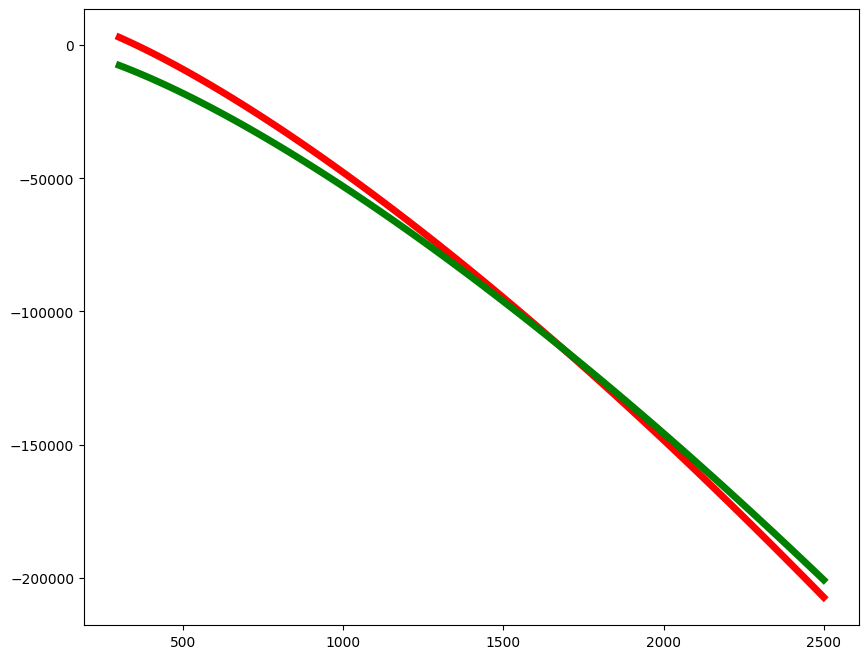

In [19]:
fig, ax1 = plt.subplots(1, 1, figsize=[10, 8], frameon=True)
ax1.set_facecolor((0, 0, 0, 0))
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.2)
ax1.plot(temp_LIQ_TDB, F_LIQ_TDB, c='r', lw=5, label='LIQUID')
ax1.plot(temp_FCC_TDB, F_FCC_TDB, c='g', lw=5, label='FCC')


In [20]:
# Define fixed compositions and range for c_Co
c_Cr, c_Fe = 0.25, 0.25
c_Co_values = np.arange(0.2, 0.35, 0.05)  # 0.2, 0.25, 0.3
temp = np.linspace(300, 2500, 100)

# Initialize arrays to store Gibbs free energy
F_LIQ_data = np.zeros((len(c_Co_values), len(temp)))
F_FCC_data = np.zeros((len(c_Co_values), len(temp)))


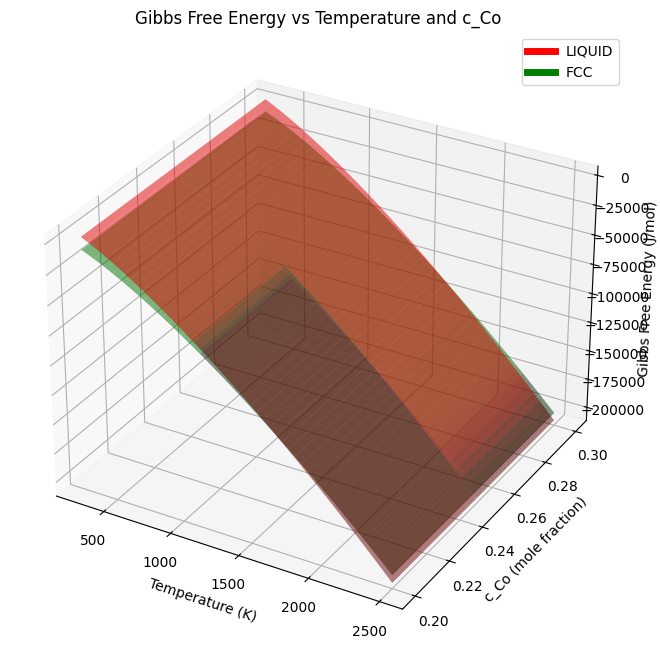

In [21]:
# Compute Gibbs free energy for each c_Co
for i, c_Co in enumerate(c_Co_values):
    c_Ni = 1 - c_Co - c_Cr - c_Fe
    if c_Ni < 0:
        print(f"Warning: c_Ni = {c_Ni} is negative for c_Co = {c_Co}. Skipping.")
        continue
    
    # Substitute compositions
    LIQ_G = G_LIQ.subs({'cA1': c_Co, 'cB1': c_Cr, 'cC1': c_Fe})
    FCC_G = G_FCC.subs({'cA2': c_Co, 'cB2': c_Cr, 'cC2': c_Fe})
    
    # Convert to callable functions
    temperature_subs_LIQ = sp.lambdify('temp', LIQ_G, modules="numpy")
    temperature_subs_FCC = sp.lambdify('temp', FCC_G, modules="numpy")
    
    # Evaluate Gibbs free energy
    F_LIQ_data[i] = temperature_subs_LIQ(temp)
    F_FCC_data[i] = temperature_subs_FCC(temp)

# Create 3D plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Create mesh for c_Co and temperature
C_CO, TEMP = np.meshgrid(c_Co_values, temp)

# Plot surfaces for LIQUID and FCC
ax.plot_surface(TEMP.T, C_CO.T, F_LIQ_data, color='red', alpha=0.5, label='LIQUID')
ax.plot_surface(TEMP.T, C_CO.T, F_FCC_data, color='green', alpha=0.5, label='FCC')

# Set labels
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('c_Co (mole fraction)')
ax.set_zlabel('Gibbs Free Energy (J/mol)')

# Create custom legend
liquid_patch = Line2D([0], [0], color='red', lw=5, label='LIQUID')
fcc_patch = Line2D([0], [0], color='green', lw=5, label='FCC')
ax.legend(handles=[liquid_patch, fcc_patch])

plt.title('Gibbs Free Energy vs Temperature and c_Co')
plt.show()